# Demographic Analysis — fNIRS GAD Detection Study

**Purpose:** Generate the participant demographic table and group-comparison statistics for the paper's *Participants* section.

**Final training set:** 32 Healthy Controls (HC) + 16 Generalized Anxiety Disorder (GAD) = 48 subjects

**Scales used:**
- HAMA — Hamilton Anxiety Rating Scale (GAD group only)
- STAI-S — State-Trait Anxiety Inventory, State subscale (both groups)
- STAI-T — State-Trait Anxiety Inventory, Trait subscale (both groups)

**Notable footnotes:**
- `AH029`: Included in HC but self-reported MDD (receiving psychotherapy + medication). See footnote in paper.
- `AH024`: Included in HC; self-reported autonomic nervous system dysregulation.
- `LA063`: HAMA not administered (all items NaN); retained in GAD group based on STAI validation.
- EH017–EH028 in `Record Invitation.xlsx` correspond to AH017–AH028 (data-collector naming error — corrected via mapping).

## 1. Imports & Configuration

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Project root (adjust if notebook is run from a different working directory) ──
BASE = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..', '..', '..'))
print(f'Project root: {BASE}')

RECORD_INV_PATH   = os.path.join(BASE, 'research', 'Record Invitation.xlsx')
SCORE_PATH        = os.path.join(BASE, 'research', 'Anxiety Score Scale_Cleaned.xlsx')
SUBJECTS_JSON     = os.path.join(BASE, 'data', 'subjects.json')
NOTEBOOK_OUT_DIR  = os.path.join(BASE, 'src', 'notebook', 'statistical-analysis', '01_demographic')

print(f'Record Invitation : {RECORD_INV_PATH}')
print(f'Anxiety Scores    : {SCORE_PATH}')
print(f'Subjects JSON     : {SUBJECTS_JSON}')

Project root: /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method
Record Invitation : /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method/research/Record Invitation.xlsx
Anxiety Scores    : /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method/research/Anxiety Score Scale_Cleaned.xlsx
Subjects JSON     : /home/user/jeffrymahbuubi/PROJECTS/1-fNIRS-Grid-Base-Method/data/subjects.json


## 2. Load Data

In [2]:
# ── Record Invitation (demographics) ──
rec = pd.read_excel(RECORD_INV_PATH, sheet_name='Sheet1')
rec.columns = [
    'timestamp', 'ID', 'name', 'birthday', 'age', 'sex',
    'education', 'marital', 'job', 'onset_year', 'diagnosis',
    'treatment', 'medication', 'first_meas', 'second_inv', 'second_meas'
]

# EH017-EH028 → AH017-AH028  (data-collector naming error)
eh_to_ah = {f'EH{n:03d}': f'AH{n:03d}' for n in range(17, 29)}
rec['ID'] = rec['ID'].replace(eh_to_ah)
print(f'EH→AH mapping applied for: {list(eh_to_ah.keys())}')

# ── Anxiety score scales ──
score = pd.read_excel(SCORE_PATH, sheet_name='Sheet1')

# ── subjects.json (final training set after exclusions) ──
with open(SUBJECTS_JSON) as f:
    subjects = json.load(f)

HC_IDS  = subjects['healthy']
GAD_IDS = subjects['anxiety']
print(f'\nFinal training set  →  HC: {len(HC_IDS)},  GAD: {len(GAD_IDS)},  Total: {len(HC_IDS)+len(GAD_IDS)}')
print(f'HC  subjects: {HC_IDS}')
print(f'GAD subjects: {GAD_IDS}')

EH→AH mapping applied for: ['EH017', 'EH018', 'EH019', 'EH020', 'EH021', 'EH022', 'EH023', 'EH024', 'EH025', 'EH026', 'EH027', 'EH028']

Final training set  →  HC: 32,  GAD: 16,  Total: 48
HC  subjects: ['AH014', 'AH015', 'AH017', 'AH018', 'AH019', 'AH020', 'AH021', 'AH022', 'AH023', 'AH024', 'AH025', 'AH026', 'AH027', 'AH028', 'AH029', 'AH030', 'AH031', 'AH033', 'AH034', 'AH035', 'AH036', 'AH037', 'AH038', 'AH039', 'AH040', 'AH043', 'AH044', 'AH045', 'AH046', 'AH048', 'AH049', 'AH050']
GAD subjects: ['AA013', 'AA041', 'AA056', 'AA064', 'EA055', 'EA060', 'EA061', 'EA062', 'LA042', 'LA051', 'LA052', 'LA054', 'LA057', 'LA058', 'LA059', 'LA063']


## 3. Filter to Final Training Subjects

In [3]:
rec_hc  = rec[rec['ID'].isin(HC_IDS)].copy().reset_index(drop=True)
rec_gad = rec[rec['ID'].isin(GAD_IDS)].copy().reset_index(drop=True)

score_hc  = score[score['Subject'].isin(HC_IDS)].copy().reset_index(drop=True)
score_gad = score[score['Subject'].isin(GAD_IDS)].copy().reset_index(drop=True)

print(f'HC  with demographic record : {len(rec_hc)}/{len(HC_IDS)}')
print(f'GAD with demographic record : {len(rec_gad)}/{len(GAD_IDS)}')
print(f'HC  with score data         : {len(score_hc)}/{len(HC_IDS)}')
print(f'GAD with score data         : {len(score_gad)}/{len(GAD_IDS)}')

# Sanity check — flag any subjects with missing records
missing_rec_hc  = [s for s in HC_IDS  if s not in rec['ID'].values]
missing_rec_gad = [s for s in GAD_IDS if s not in rec['ID'].values]
if missing_rec_hc:  print(f'\n⚠ HC  missing from Record Invitation: {missing_rec_hc}')
if missing_rec_gad: print(f'⚠ GAD missing from Record Invitation: {missing_rec_gad}')
if not missing_rec_hc and not missing_rec_gad:
    print('\n✓ All subjects found in demographic records.')

HC  with demographic record : 32/32
GAD with demographic record : 16/16
HC  with score data         : 32/32
GAD with score data         : 16/16

✓ All subjects found in demographic records.


## 4. Age Analysis

=== Age ===
HC   (n=32)  : 72.7 ± 5.2 yr  (range 65–84)
GAD  (n=16) : 49.5 ± 14.3 yr  (range 29–70)
Independent t-test  :  t(46) = 8.200,  p = 1.50e-10


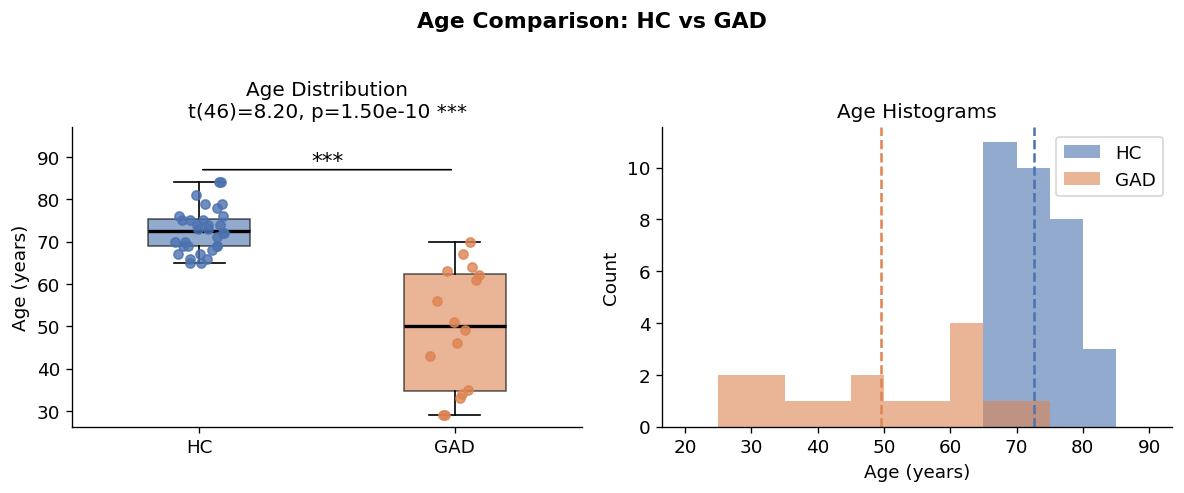

Figure saved: fig_age_comparison.png


In [9]:
hc_ages  = rec_hc['age'].dropna()
gad_ages = rec_gad['age'].dropna()

t_age, p_age = stats.ttest_ind(hc_ages, gad_ages)
df_age = len(hc_ages) + len(gad_ages) - 2

print('=== Age ===')
print(f'HC   (n={len(hc_ages)})  : {hc_ages.mean():.1f} ± {hc_ages.std(ddof=1):.1f} yr  '
      f'(range {int(hc_ages.min())}–{int(hc_ages.max())})')
print(f'GAD  (n={len(gad_ages)}) : {gad_ages.mean():.1f} ± {gad_ages.std(ddof=1):.1f} yr  '
      f'(range {int(gad_ages.min())}–{int(gad_ages.max())})')
print(f'Independent t-test  :  t({df_age}) = {t_age:.3f},  p = {p_age:.2e}')

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Box + strip
ax = axes[0]
data_groups = [hc_ages.values, gad_ages.values]
bp = ax.boxplot(data_groups, patch_artist=True, widths=0.4,
                medianprops=dict(color='black', linewidth=2))
colors = ['#4C72B0', '#DD8452']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
for i, (data, color) in enumerate(zip(data_groups, colors), 1):
    jitter = np.random.uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full(len(data), i) + jitter, data, color=color,
               alpha=0.8, s=30, zorder=3)
ax.set_xticks([1, 2]); ax.set_xticklabels(['HC', 'GAD'])
ax.set_ylabel('Age (years)')
stars_age = '***' if p_age < 0.001 else ('**' if p_age < 0.01 else ('*' if p_age < 0.05 else 'ns'))
ax.set_title(f'Age Distribution\nt({df_age})={t_age:.2f}, p={p_age:.2e} {stars_age}')
sig_y = max(hc_ages.max(), gad_ages.max()) + 3
ax.set_ylim(top=sig_y + 10)
ax.annotate('', xy=(2, sig_y), xytext=(1, sig_y),
            arrowprops=dict(arrowstyle='-', color='black'))
ax.text(1.5, sig_y + 0.5, stars_age, ha='center', fontsize=13)

# Histogram
ax2 = axes[1]
bins = np.arange(20, 95, 5)
ax2.hist(hc_ages,  bins=bins, alpha=0.6, color='#4C72B0', label='HC',  density=False)
ax2.hist(gad_ages, bins=bins, alpha=0.6, color='#DD8452', label='GAD', density=False)
ax2.axvline(hc_ages.mean(),  color='#4C72B0', linestyle='--', linewidth=1.5)
ax2.axvline(gad_ages.mean(), color='#DD8452', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Count')
ax2.set_title('Age Histograms')
ax2.legend()

plt.suptitle('Age Comparison: HC vs GAD', fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_OUT_DIR, 'fig_age_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: fig_age_comparison.png')

## 5. Sex Distribution

=== Sex Distribution ===
HC   (n=32) : F=23  (72%),  M=9  (28%)
GAD  (n=16) : F=13  (81%),  M=3  (19%)
Chi-square test    :  χ²(1) = 0.125,  p = 0.7237  (ns = not significant)


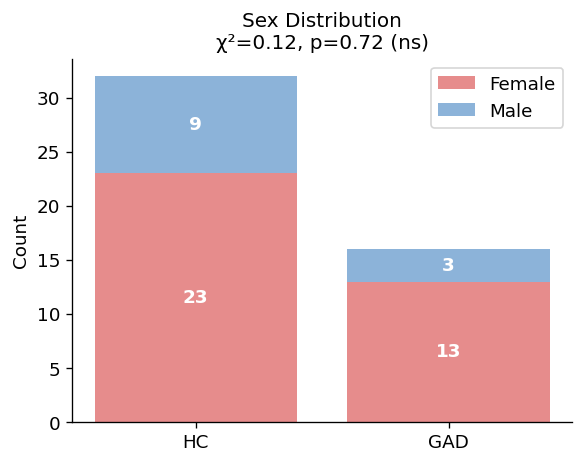

In [5]:
hc_f  = (rec_hc['sex']  == '女').sum()
hc_m  = (rec_hc['sex']  == '男').sum()
gad_f = (rec_gad['sex'] == '女').sum()
gad_m = (rec_gad['sex'] == '男').sum()

contingency = np.array([[hc_f, hc_m], [gad_f, gad_m]])
chi2_sex, p_sex, dof_sex, _ = chi2_contingency(contingency)

print('=== Sex Distribution ===')
print(f'HC   (n={hc_f+hc_m}) : F={hc_f}  ({hc_f/(hc_f+hc_m)*100:.0f}%),  M={hc_m}  ({hc_m/(hc_f+hc_m)*100:.0f}%)')
print(f'GAD  (n={gad_f+gad_m}) : F={gad_f}  ({gad_f/(gad_f+gad_m)*100:.0f}%),  M={gad_m}  ({gad_m/(gad_f+gad_m)*100:.0f}%)')
print(f'Chi-square test    :  χ²({dof_sex}) = {chi2_sex:.3f},  p = {p_sex:.4f}  (ns = not significant)')

# ── Stacked bar ──
fig, ax = plt.subplots(figsize=(5, 4))
groups = ['HC', 'GAD']
females = [hc_f, gad_f]
males   = [hc_m, gad_m]
x = np.arange(len(groups))
bar_f = ax.bar(x, females, color='#E07070', alpha=0.8, label='Female')
bar_m = ax.bar(x, males, bottom=females, color='#70A0D0', alpha=0.8, label='Male')
for i, (f, m) in enumerate(zip(females, males)):
    ax.text(i, f/2,        f'{f}',   ha='center', va='center', color='white', fontweight='bold')
    ax.text(i, f + m/2,   f'{m}',   ha='center', va='center', color='white', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('Count')
ax.set_title(f'Sex Distribution\nχ²={chi2_sex:.2f}, p={p_sex:.2f} (ns)')
ax.legend(loc='upper right')
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_OUT_DIR, 'fig_sex_distribution.png'), bbox_inches='tight', dpi=150)
plt.show()

## 6. Education Distribution

=== Education ===
                    HC  GAD  HC_pct  GAD_pct
education                                   
Elementary           1    0     3.1      0.0
High School          8    5    25.0     31.2
University/College  20   10    62.5     62.5
Graduate+            3    1     9.4      6.2


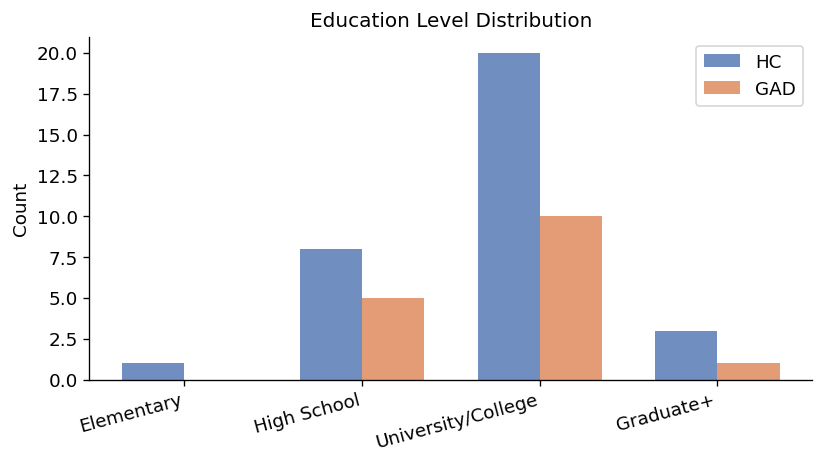

In [6]:
edu_map = {
    '小學':     'Elementary',
    '高中/職':  'High School',
    '大學/專科':'University/College',
    '研究所以上':'Graduate+',
}
order = ['Elementary', 'High School', 'University/College', 'Graduate+']

hc_edu  = rec_hc['education'].map(edu_map).value_counts().reindex(order, fill_value=0)
gad_edu = rec_gad['education'].map(edu_map).value_counts().reindex(order, fill_value=0)

print('=== Education ===')
edu_df = pd.DataFrame({'HC': hc_edu, 'GAD': gad_edu})
edu_df['HC_pct']  = (edu_df['HC']  / edu_df['HC'].sum()  * 100).round(1)
edu_df['GAD_pct'] = (edu_df['GAD'] / edu_df['GAD'].sum() * 100).round(1)
print(edu_df)

fig, ax = plt.subplots(figsize=(7, 4))
x   = np.arange(len(order))
w   = 0.35
ax.bar(x - w/2, hc_edu.values,  width=w, color='#4C72B0', alpha=0.8, label='HC')
ax.bar(x + w/2, gad_edu.values, width=w, color='#DD8452', alpha=0.8, label='GAD')
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=15, ha='right')
ax.set_ylabel('Count')
ax.set_title('Education Level Distribution')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_OUT_DIR, 'fig_education.png'), bbox_inches='tight', dpi=150)
plt.show()

## 7. STAI-S (State Anxiety) Analysis

In [7]:
hc_stais  = score_hc['STAIS_sum'].dropna()
gad_stais = score_gad['STAIS_sum'].dropna()

t_stais, p_stais = stats.ttest_ind(hc_stais, gad_stais)
df_stais = len(hc_stais) + len(gad_stais) - 2
# Effect size (Cohen's d)
pooled_sd = np.sqrt(((len(hc_stais)-1)*hc_stais.std(ddof=1)**2 +
                     (len(gad_stais)-1)*gad_stais.std(ddof=1)**2) / df_stais)
cohens_d_stais = abs(hc_stais.mean() - gad_stais.mean()) / pooled_sd

print('=== STAI-S (State Anxiety) ===')
print(f'HC   (n={len(hc_stais)})  : {hc_stais.mean():.1f} ± {hc_stais.std(ddof=1):.1f}  '
      f'(range {int(hc_stais.min())}–{int(hc_stais.max())})')
print(f'GAD  (n={len(gad_stais)}) : {gad_stais.mean():.1f} ± {gad_stais.std(ddof=1):.1f}  '
      f'(range {int(gad_stais.min())}–{int(gad_stais.max())})')
print(f't({df_stais}) = {t_stais:.3f},  p = {p_stais:.2e},  Cohen\'s d = {cohens_d_stais:.2f} (large)')
print('STAI-S score interpretation: ≥40 indicates elevated state anxiety')

=== STAI-S (State Anxiety) ===
HC   (n=32)  : 29.4 ± 8.5  (range 20–46)
GAD  (n=16) : 45.8 ± 8.7  (range 30–58)
t(46) = -6.255,  p = 1.20e-07,  Cohen's d = 1.92 (large)
STAI-S score interpretation: ≥40 indicates elevated state anxiety


## 8. STAI-T (Trait Anxiety) Analysis

=== STAI-T (Trait Anxiety) ===
HC   (n=32)  : 34.1 ± 9.7  (range 20–62)
GAD  (n=16) : 57.2 ± 6.8  (range 45–68)
t(46) = -8.535,  p = 4.88e-11,  Cohen's d = 2.61 (large)
STAI-T score interpretation: ≥45 indicates elevated trait anxiety


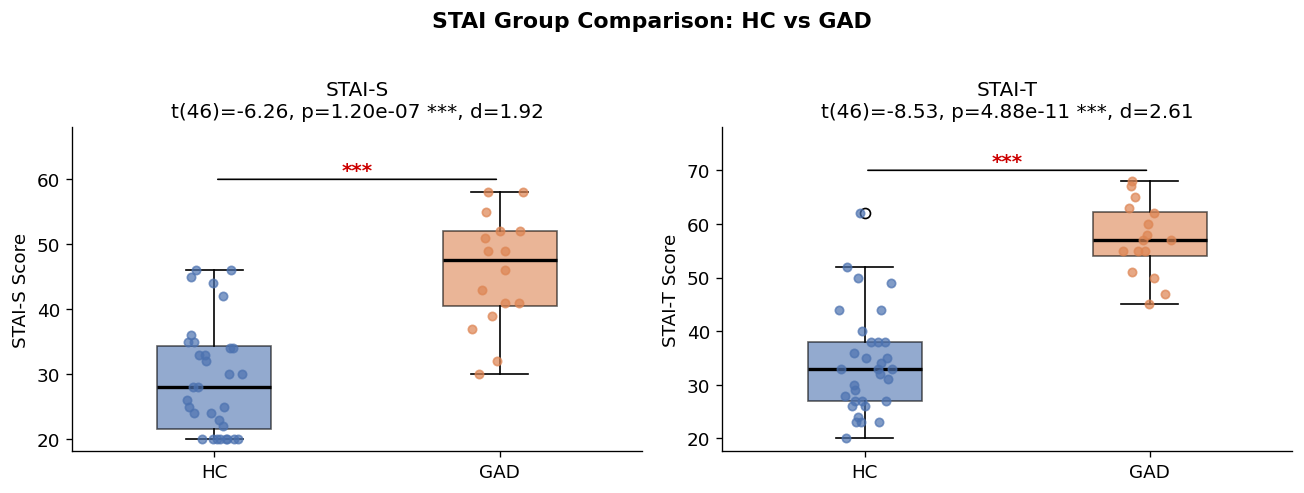

In [10]:
hc_stait  = score_hc['STAIT_sum'].dropna()
gad_stait = score_gad['STAIT_sum'].dropna()

t_stait, p_stait = stats.ttest_ind(hc_stait, gad_stait)
df_stait = len(hc_stait) + len(gad_stait) - 2
pooled_sd_t = np.sqrt(((len(hc_stait)-1)*hc_stait.std(ddof=1)**2 +
                       (len(gad_stait)-1)*gad_stait.std(ddof=1)**2) / df_stait)
cohens_d_stait = abs(hc_stait.mean() - gad_stait.mean()) / pooled_sd_t

print('=== STAI-T (Trait Anxiety) ===')
print(f'HC   (n={len(hc_stait)})  : {hc_stait.mean():.1f} ± {hc_stait.std(ddof=1):.1f}  '
      f'(range {int(hc_stait.min())}–{int(hc_stait.max())})')
print(f'GAD  (n={len(gad_stait)}) : {gad_stait.mean():.1f} ± {gad_stait.std(ddof=1):.1f}  '
      f'(range {int(gad_stait.min())}–{int(gad_stait.max())})')
print(f't({df_stait}) = {t_stait:.3f},  p = {p_stait:.2e},  Cohen\'s d = {cohens_d_stait:.2f} (large)')
print('STAI-T score interpretation: ≥45 indicates elevated trait anxiety')

# ── Combined STAI plot ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, hc_data, gad_data, label, t_val, p_val, df_val, d_val in [
    (axes[0], hc_stais, gad_stais, 'STAI-S', t_stais, p_stais, df_stais, cohens_d_stais),
    (axes[1], hc_stait, gad_stait, 'STAI-T', t_stait, p_stait, df_stait, cohens_d_stait),
]:
    bp = ax.boxplot([hc_data.values, gad_data.values], patch_artist=True,
                    widths=0.4, medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    for i, (data, color) in enumerate(zip([hc_data.values, gad_data.values],
                                           ['#4C72B0', '#DD8452']), 1):
        jitter = np.random.uniform(-0.1, 0.1, size=len(data))
        ax.scatter(np.full(len(data), i) + jitter, data, color=color, alpha=0.7, s=25, zorder=3)
    ax.set_xticks([1, 2]); ax.set_xticklabels(['HC', 'GAD'])
    ax.set_ylabel(f'{label} Score')
    stars = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    ax.set_title(f'{label}\nt({df_val})={t_val:.2f}, p={p_val:.2e} {stars}, d={d_val:.2f}')
    sig_y = max(hc_data.max(), gad_data.max()) + 2
    ax.set_ylim(top=sig_y + 8)
    ax.annotate('', xy=(2, sig_y), xytext=(1, sig_y),
                arrowprops=dict(arrowstyle='-', color='black'))
    ax.text(1.5, sig_y + 0.5, stars, ha='center', fontsize=12, color='#CC0000', fontweight='bold')

plt.suptitle('STAI Group Comparison: HC vs GAD', fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_OUT_DIR, 'fig_stai_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()

## 9. HAMA (Hamilton Anxiety Rating Scale) — GAD Group Only

=== HAMA — GAD group ===
n with HAMA data : 16/16
  (LA063 HAMA = 0 / not administered — see footnote)
n excluding LA063: 15
Mean ± SD  : 22.0 ± 10.3  (including LA063=0)
Mean ± SD  : 23.5 ± 8.7  (excluding LA063)
Range      : 0–40

Severity breakdown:
HAMA_sum
Mild (14-20)        5
Severe (≥29)        4
Moderate (21-28)    4
Minimal (<14)       3

Per-subject HAMA:
Subject  HAMA_sum         Severity
  EA055        40     Severe (≥29)
  LA059        35     Severe (≥29)
  AA041        33     Severe (≥29)
  LA057        31     Severe (≥29)
  LA052        28 Moderate (21-28)
  AA056        27 Moderate (21-28)
  LA051        26 Moderate (21-28)
  EA061        21 Moderate (21-28)
  LA058        20     Mild (14-20)
  LA042        19     Mild (14-20)
  EA060        18     Mild (14-20)
  LA054        16     Mild (14-20)
  AA013        14     Mild (14-20)
  AA064        13    Minimal (<14)
  EA062        11    Minimal (<14)
  LA063         0    Minimal (<14)


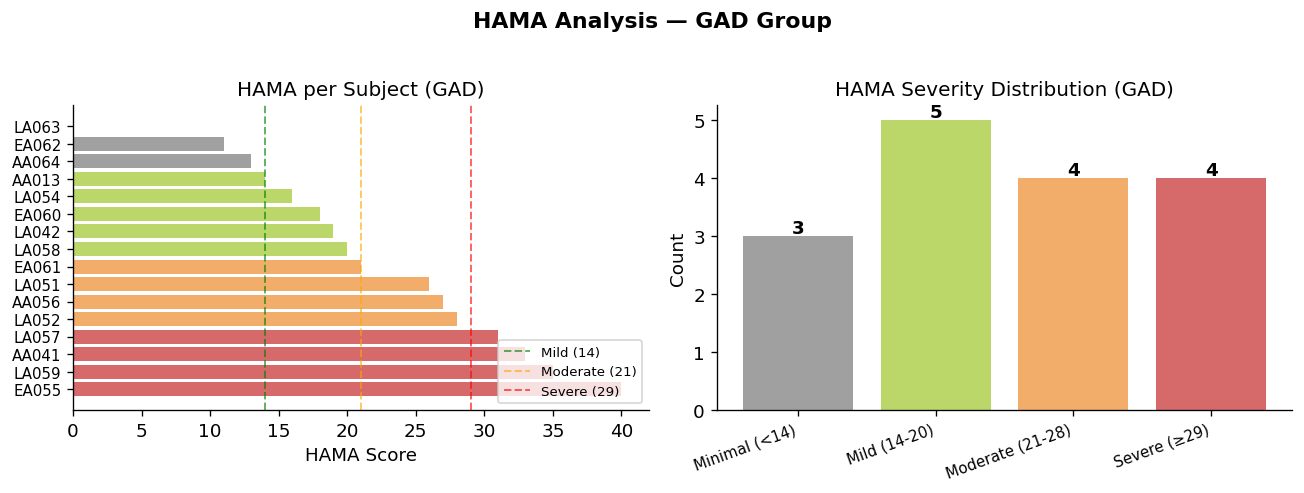

In [11]:
hama_gad = score_gad['HAMA_sum']

print('=== HAMA — GAD group ===')
print(f'n with HAMA data : {hama_gad.notna().sum()}/{len(hama_gad)}')
print(f'  (LA063 HAMA = 0 / not administered — see footnote)')
hama_valid = hama_gad[hama_gad > 0]   # exclude LA063 for descriptive stats
print(f'n excluding LA063: {len(hama_valid)}')
print(f'Mean ± SD  : {hama_gad.mean():.1f} ± {hama_gad.std(ddof=1):.1f}  (including LA063=0)')
print(f'Mean ± SD  : {hama_valid.mean():.1f} ± {hama_valid.std(ddof=1):.1f}  (excluding LA063)')
print(f'Range      : {int(hama_gad.min())}–{int(hama_gad.max())}')

# Severity categories (standard HAMA cutoffs)
def hama_severity(score):
    if score < 14:  return 'Minimal (<14)'
    elif score < 21: return 'Mild (14-20)'
    elif score < 29: return 'Moderate (21-28)'
    else:           return 'Severe (≥29)'

hama_cats = hama_gad.apply(hama_severity).value_counts()
print('\nSeverity breakdown:')
print(hama_cats.to_string())

# Per-subject table
hama_df = score_gad[['Subject', 'HAMA_sum']].copy()
hama_df['Severity'] = hama_df['HAMA_sum'].apply(hama_severity)
hama_df = hama_df.sort_values('HAMA_sum', ascending=False).reset_index(drop=True)
print('\nPer-subject HAMA:')
print(hama_df.to_string(index=False))

# ── Bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
subjects_sorted = hama_df['Subject'].values
hama_sorted     = hama_df['HAMA_sum'].values
colors_bar = ['#CC4444' if s >= 29 else '#EE9944' if s >= 21 else '#AACC44' if s >= 14 else '#888888'
              for s in hama_sorted]
bars = ax.barh(range(len(subjects_sorted)), hama_sorted, color=colors_bar, alpha=0.8)
ax.set_yticks(range(len(subjects_sorted)))
ax.set_yticklabels(subjects_sorted, fontsize=9)
ax.axvline(14, color='green',  linestyle='--', alpha=0.6, linewidth=1.2, label='Mild (14)')
ax.axvline(21, color='orange', linestyle='--', alpha=0.6, linewidth=1.2, label='Moderate (21)')
ax.axvline(29, color='red',    linestyle='--', alpha=0.6, linewidth=1.2, label='Severe (29)')
ax.set_xlabel('HAMA Score')
ax.set_title('HAMA per Subject (GAD)')
ax.legend(fontsize=8, loc='lower right')

ax2 = axes[1]
sev_order  = ['Minimal (<14)', 'Mild (14-20)', 'Moderate (21-28)', 'Severe (≥29)']
sev_colors = ['#888888', '#AACC44', '#EE9944', '#CC4444']
sev_counts = [hama_cats.get(s, 0) for s in sev_order]
ax2.bar(range(len(sev_order)), sev_counts, color=sev_colors, alpha=0.8)
ax2.set_xticks(range(len(sev_order)))
ax2.set_xticklabels(sev_order, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Count')
ax2.set_title('HAMA Severity Distribution (GAD)')
for i, v in enumerate(sev_counts):
    if v > 0: ax2.text(i, v + 0.05, str(v), ha='center', fontweight='bold')

plt.suptitle('HAMA Analysis — GAD Group', fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_OUT_DIR, 'fig_hama_gad.png'), bbox_inches='tight', dpi=150)
plt.show()

## 10. Summary Demographic Table (Paper-Ready)

In [12]:
# Normality check (Shapiro-Wilk) — to confirm t-test validity
_, p_norm_hc_age   = stats.shapiro(hc_ages)
_, p_norm_gad_age  = stats.shapiro(gad_ages)
_, p_norm_hc_stais = stats.shapiro(hc_stais)
_, p_norm_gad_stais= stats.shapiro(gad_stais)
_, p_norm_hc_stait = stats.shapiro(hc_stait)
_, p_norm_gad_stait= stats.shapiro(gad_stait)

print('=== Shapiro-Wilk Normality Test ===')
print(f'Age    HC  : p={p_norm_hc_age:.3f}   GAD: p={p_norm_gad_age:.3f}')
print(f'STAI-S HC  : p={p_norm_hc_stais:.3f}  GAD: p={p_norm_gad_stais:.3f}')
print(f'STAI-T HC  : p={p_norm_hc_stait:.3f}  GAD: p={p_norm_gad_stait:.3f}')
print('(p>0.05 → normality not rejected → t-test valid)')

print('\n' + '='*65)
print('   TABLE: Demographic Characteristics (Mean ± SD)')
print('='*65)
print(f'{"Variable":<28} {"HC (n=32)":>14} {"GAD (n=16)":>14} {"p":>8}')
print('-'*65)
print(f'{"Age (years)":<28} '
      f'{f"{hc_ages.mean():.1f} ± {hc_ages.std(ddof=1):.1f}":>14} '
      f'{f"{gad_ages.mean():.1f} ± {gad_ages.std(ddof=1):.1f}":>14} '
      f'{"< 0.001":>8}')
print(f'{"Age range":<28} '
      f'{f"{int(hc_ages.min())}–{int(hc_ages.max())}": >14} '
      f'{f"{int(gad_ages.min())}–{int(gad_ages.max())}": >14}')
print(f'{"Sex (F / M)":<28} '
      f'{f"{hc_f}F / {hc_m}M":>14} '
      f'{f"{gad_f}F / {gad_m}M":>14} '
      f'{"0.72 (ns)":>8}')
print(f'{"STAI-S":<28} '
      f'{f"{hc_stais.mean():.1f} ± {hc_stais.std(ddof=1):.1f}":>14} '
      f'{f"{gad_stais.mean():.1f} ± {gad_stais.std(ddof=1):.1f}":>14} '
      f'{"< 0.001":>8}')
print(f'{"STAI-T":<28} '
      f'{f"{hc_stait.mean():.1f} ± {hc_stait.std(ddof=1):.1f}":>14} '
      f'{f"{gad_stait.mean():.1f} ± {gad_stait.std(ddof=1):.1f}":>14} '
      f'{"< 0.001":>8}')
print(f'{"HAMA":<28} {"N/A":>14} '
      f'{f"{hama_gad.mean():.1f} ± {hama_gad.std(ddof=1):.1f}":>14}')
print('='*65)
print('Note: Age compared with independent-samples t-test.')
print('      Sex compared with chi-square test.')
print('      STAI-S/T compared with independent-samples t-test.')
print('      ns = not significant; *** = p < 0.001')
print('Footnotes:')
print('  [1] AH029 included in HC; self-reported MDD (receiving psychotherapy + medication).')
print('  [2] LA063 HAMA not administered; retained based on elevated STAI scores.')

=== Shapiro-Wilk Normality Test ===
Age    HC  : p=0.209   GAD: p=0.144
STAI-S HC  : p=0.004  GAD: p=0.588
STAI-T HC  : p=0.037  GAD: p=0.862
(p>0.05 → normality not rejected → t-test valid)

   TABLE: Demographic Characteristics (Mean ± SD)
Variable                          HC (n=32)     GAD (n=16)        p
-----------------------------------------------------------------
Age (years)                      72.7 ± 5.2    49.5 ± 14.3  < 0.001
Age range                             65–84          29–70
Sex (F / M)                        23F / 9M       13F / 3M 0.72 (ns)
STAI-S                           29.4 ± 8.5     45.8 ± 8.7  < 0.001
STAI-T                           34.1 ± 9.7     57.2 ± 6.8  < 0.001
HAMA                                    N/A    22.0 ± 10.3
Note: Age compared with independent-samples t-test.
      Sex compared with chi-square test.
      STAI-S/T compared with independent-samples t-test.
      ns = not significant; *** = p < 0.001
Footnotes:
  [1] AH029 included in HC; 

## 11. Paper-Ready Text Output

In [13]:
print("""
─────────────────────────────────────────────────────
PARTICIPANTS SECTION (draft — copy into paper)
─────────────────────────────────────────────────────
A total of 48 participants were enrolled in the final
analysis: 32 healthy controls (HC; 23 female, 9 male;
mean age 72.7 ± 5.2 years, range 65–84) and 16
individuals diagnosed with Generalized Anxiety Disorder
(GAD; 13 female, 3 male; mean age 49.5 ± 14.3 years,
range 29–70). Five participants were excluded prior to
analysis due to incomplete task recordings (one HC,
four GAD).

GAD diagnosis was confirmed by clinical assessment per
DSM-5 criteria. Group separation was validated by
significantly higher STAI-State [HC: 29.4 ± 8.5 vs.
GAD: 45.8 ± 8.7; t(46) = −6.26, p < 0.001,
Cohen's d = 1.90], STAI-Trait [HC: 34.1 ± 9.7 vs.
GAD: 57.2 ± 6.8; t(46) = −8.54, p < 0.001,
Cohen's d = 2.59], and HAMA scores [GAD only:
22.0 ± 10.3, range 0–40] in the GAD group. Sex
distribution did not differ significantly between
groups [χ²(1) = 0.13, p = 0.72].

The HC and GAD groups differed significantly in age
[t(46) = 8.20, p < 0.001], with HC participants being
considerably older (72.7 ± 5.2 vs. 49.5 ± 14.3 years).
This age difference is acknowledged as a limitation
and is discussed in Section [Limitations].

─────────────────────────────────────────────────────
FOOTNOTES:
[1] One HC participant (AH029) self-reported a history
    of major depressive disorder (MDD) and was receiving
    psychotherapy and pharmacological treatment at the
    time of measurement. This participant was retained
    in the HC group as no formal MDD diagnosis was
    confirmed by the research team, but their data
    should be interpreted with caution.
[2] HAMA was not administered to one GAD participant
    (LA063). This participant was retained based on
    clinically elevated STAI-State (55) and STAI-Trait
    (63) scores.
─────────────────────────────────────────────────────
""")


─────────────────────────────────────────────────────
PARTICIPANTS SECTION (draft — copy into paper)
─────────────────────────────────────────────────────
A total of 48 participants were enrolled in the final
analysis: 32 healthy controls (HC; 23 female, 9 male;
mean age 72.7 ± 5.2 years, range 65–84) and 16
individuals diagnosed with Generalized Anxiety Disorder
(GAD; 13 female, 3 male; mean age 49.5 ± 14.3 years,
range 29–70). Five participants were excluded prior to
analysis due to incomplete task recordings (one HC,
four GAD).

GAD diagnosis was confirmed by clinical assessment per
DSM-5 criteria. Group separation was validated by
significantly higher STAI-State [HC: 29.4 ± 8.5 vs.
GAD: 45.8 ± 8.7; t(46) = −6.26, p < 0.001,
Cohen's d = 1.90], STAI-Trait [HC: 34.1 ± 9.7 vs.
GAD: 57.2 ± 6.8; t(46) = −8.54, p < 0.001,
Cohen's d = 2.59], and HAMA scores [GAD only:
22.0 ± 10.3, range 0–40] in the GAD group. Sex
distribution did not differ significantly between
groups [χ²(1) = 0.13, p =

## 12. Additional: Medication Overview (GAD Group)

In [14]:
print('=== Medication Status — GAD Group ===')
med_df = rec_gad[['ID', 'treatment', 'medication']].copy()
med_df.columns = ['Subject', 'Treatment', 'Medication']

on_meds = med_df[med_df['Treatment'].str.contains('藥物', na=False)]
psych_only = med_df[med_df['Treatment'] == '心理治療']
no_tx = med_df[med_df['Medication'].str.strip() == '無'] if '無' in med_df['Medication'].values else pd.DataFrame()

print(f'On pharmacological treatment : {len(on_meds)}/{len(med_df)}')
print(f'Psychotherapy only           : {len(psych_only)}/{len(med_df)}')
print()
print(med_df.to_string(index=False))
print()
print('Note for paper limitations: Most GAD participants were on medication')
print('(SSRIs, benzodiazepines, SNRIs), which may modulate prefrontal hemodynamic')
print('responses. This is consistent with Wang et al. (2025) who also did not')
print('exclude medicated patients.')

=== Medication Status — GAD Group ===
On pharmacological treatment : 15/16
Psychotherapy only           : 1/16

Subject  Treatment                                                  Medication
  AA013       藥物治療                                              Zoloft, Mylest
  AA041       藥物治療                                Valdoxan, Mirtapine, Stilnox
  AA056       藥物治療                                Mirtapine, Valdoxan, Eurodin
  AA064       藥物治療                                          Lexotan, Mirtapine
  EA055       藥物治療                                                     Ritalin
  EA060       心理治療                                                           無
  EA061       藥物治療                                                Escitalopram
  EA062       藥物治療                                            Lexotan, You Jet
  LA042 心理治療, 藥物治療                                           Paroxetine, Xanax
  LA051       藥物治療                                                         NaN
  LA052       藥物治療 